In [23]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
pose_path = "public_si_dat/pose_train_data.pkl"
annotation_path = "public_si_dat/train_10.txt"
mode = "SI"
split_type = "train"


In [5]:
with open(pose_path, 'rb') as f:
    pose_dict = pickle.load(f)

In [6]:
annotations = pd.read_csv(annotation_path, delimiter='|')

In [7]:
ids = [str(i) for i in annotations['id'] if str(i) in pose_dict]

In [53]:
def _build_vocab():
    glosses = set()
    for gloss in annotations['gloss']:
        if pd.notna(gloss):  # Handle NaN values
            glosses.update(gloss.split())
    return {g: i+1 for i, g in enumerate(sorted(glosses))}

In [58]:
vocab = _build_vocab()
vocab["<unk>"] = len(vocab) + 1  # Unknown token
vocab["<pad>"] = 0  # Padding token

In [ ]:
glosses

In [44]:
pose_sample = pose_dict["03_0753"]["keypoints"]

right_hand = pose_sample[:, 0:21, :2]
left_hand = pose_sample[:, 21:42, :2]
lips = pose_sample[:, 42:42+19, :2]
body = pose_sample[:, 42+19:, :2]

def normalize(joints): # joints.shape = (J, 2)
    if np.sum(joints) == 0: return joints
    joints -= joints[0]
    max_val = np.max(np.abs(joints))
    return joints / max_val if max_val > 0 else joints

right_hand = np.array([normalize(f) for f in right_hand])
left_hand = np.array([normalize(f) for f in left_hand])
lips = np.array([normalize(f) for f in lips])
body = np.array([normalize(f) for f in body])

concatenated = np.concatenate([right_hand, left_hand, lips, body], axis=1) # (T, 86, 2)

processed_pose = concatenated.reshape(concatenated.shape[0], -1)

In [45]:
processed_pose.shape

(171, 172)

In [35]:
right_hand[100]

array([[ 0.        ,  0.        ],
       [ 0.1181491 , -0.25372451],
       [ 0.33563011, -0.37834536],
       [ 0.51843177, -0.43784198],
       [ 0.60464723, -0.5310792 ],
       [ 0.58849424, -0.13218585],
       [ 0.81179036, -0.06020101],
       [ 0.9174846 ,  0.0040486 ],
       [ 1.        ,  0.06060821],
       [ 0.57706683,  0.01480059],
       [ 0.77965333,  0.06971674],
       [ 0.88612842,  0.10334178],
       [ 0.96950084,  0.13299407],
       [ 0.52394298,  0.11585377],
       [ 0.68993654,  0.14120975],
       [ 0.80084911,  0.15490493],
       [ 0.87680026,  0.16297284],
       [ 0.46075787,  0.18192911],
       [ 0.58488854,  0.17244202],
       [ 0.66802198,  0.16694527],
       [ 0.72706088,  0.16036328]])

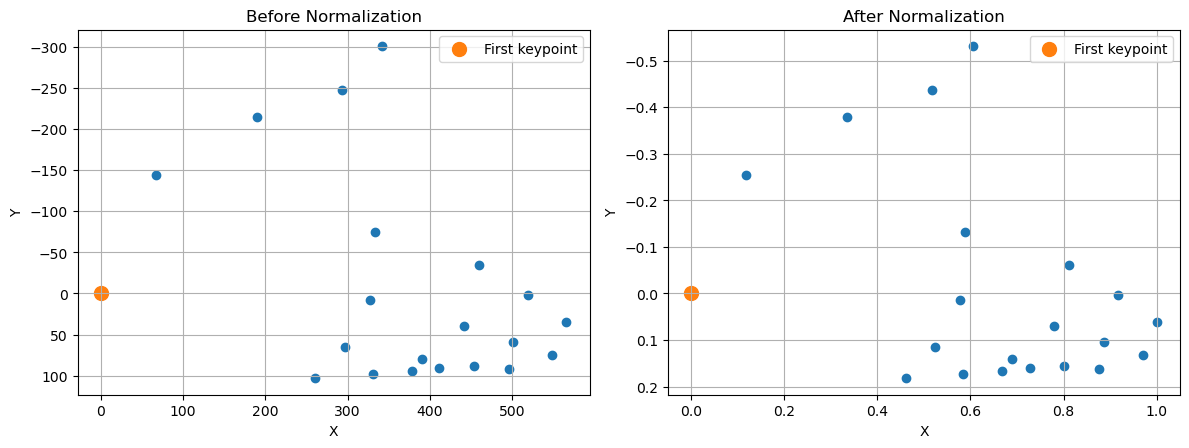

In [40]:
def visualize_normalization(joints):
    """
    joints: numpy array có shape (N, 2)
            N = số lượng keypoint
            2 = (x, y)
    """

    normalized = normalize(joints)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Trước normalize
    axes[0].scatter(joints[:, 0], joints[:, 1])
    axes[0].scatter(
        joints[0, 0],
        joints[0, 1],
        s=100,
        label="First keypoint"
    )

    axes[0].set_title("Before Normalization")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")
    axes[0].grid(True)
    axes[0].legend()
    axes[0].set_aspect("equal")
    axes[0].invert_yaxis()

    # Sau normalize
    axes[1].scatter(normalized[:, 0], normalized[:, 1])
    axes[1].scatter(
        normalized[0, 0],
        normalized[0, 1],
        s=100,
        label="First keypoint"
    )

    axes[1].set_title("After Normalization")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")
    axes[1].grid(True)
    axes[1].legend()
    axes[1].set_aspect("equal")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

visualize_normalization(right_hand[100])

In [ ]:
print(right_hand)

In [51]:
sample_id = "03_0753"
gloss = annotations[annotations["id"] == sample_id]["gloss"].iloc[0]
print(gloss)

طفل طفل بكاء سبب جوع


In [59]:
label = [vocab.get(g, vocab["<unk>"]) for g in gloss.split()]

In [60]:
label

[357, 357, 107, 283, 183]